<a href="https://colab.research.google.com/github/nagamamo/machine_learning_for_finance/blob/main/3_1_standard_monte_carlo_and_stock_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**３．１**　**標準モンテカルロ法と株価予測**

　本例は、標準モンテカルロ法による株価予測モデルを、日経平均株価の標本データを用いて実装します。市場インデックスの予測が、実務の現場で重視される理由は、シングル・ファクター・モデルやマルチ・ファクター・モデルにより個別銘柄の株価予測を行う際に、マーケット・ポートフォリオに市場インデックス株価を用いるケースが多いためです。そして、CAPM理論に機械学習を応用する実装手順を解説する本デポジトリにおいても、この市場インデックス株価の予測が不可欠となります。

　本例では、まずデータ管理、数値計算用にpandas、numpy、math、スクレイピングによる株価データ取得のためのpandas_datareader、確率分布に基づく乱数を発生させるためのrandom、そして図表作成用のライブラリmatplotlibを読み込みます。

In [1]:
#[1]ライブラリの読み込み
import pandas as pd
from pandas_datareader import data
import numpy as np
from math import exp,sqrt
import random
import matplotlib.pyplot as plt

　次に日経平均株価の日次データを取得します。本例では、pandasデータフレームの名称をNKXとして、pandas_datareaderにより、2000年1月1日から2025年12月30日の日次データを取得します。得られた日次データから、終値（Close）を抽出して同様にデータフレームNKXの名称を上書きし、データフレーム内のデータ名をCloseからnikkeiに修正します。尚、本例では、日次データを月次平均値に変換しています。最後に、直近の実績値をlastというデータフレーム名で保存し、モンテカルロ法の初期値として用います。

In [ ]:
#[2]日経平均株価の時系列データと直近値の取得
NKX=data.DataReader('^NKX','stooq',start="2000-01-01",end="2025-12-30").sort_values(by='Date',ascending=True)
NKX=pd.DataFrame(NKX.Close)
NKX = NKX.rename(columns={'Close': 'nikkei'})
NKX = NKX.resample(rule = "ME").mean()
NKX.head()
last=NKX.nikkei[-1]

　続いて次のセルでは、離散化したモデルを変数とともに定義します。モデル式の名称をbsmとして、Sは日経平均株価、sigmaは標準偏差、muは平均リターン、deltaは限界的な時間の経過、ｚは乱数です。

In [3]:
#[3]株価変動モデルの定義
def bsm(S,sigma,mu,delta_t,z):
  bsm= S*exp((mu-sigma**2/2)*delta_t+sigma*sqrt(delta_t)*z)
  return bsm

　セル[4]では、株価予測モデルのシミュレーション実行回数を定義します。ひとつめの実行回数（p）は予測期間である将来何日後、何カ月後、何年後までの株価を予測するかの定義です。本例はこれを2年後まで実行するため、予測期間（p）を24カ月（p=24）とします。ふたつめの実行回数は、この24カ月のシミュレーションを何回反復するかの反復数（q）の定義です。本例では24カ月の反復を5,000回（q=5,000）実行します。この2年後の24カ月後までのデータ、5,000回の試算結果を格納するための、0を要素とする2種類のnumpy配列を生成します。初期値nikkei_F[0] にはセル[2]で生成したデータフレームlastを与えます。図表は、2026年1月1日から24カ月後の5,000回の試算結果を可視化したものです。

In [4]:
#[4]予測期間(p)と反復回数(q)の定義
p, q= 24, 5000
NKX_F=np.zeros(p)
NKX_F[0] = last
NKX_F2=np.zeros(q)

　セル[5]を実行することにより、予測期間pの反復計算がq回実行されます。まずセル[5]では、データフレームNKXのデータを月次リターンへ変換し、平均リターンmuおよび標準偏差（リスク）sigmaを計算します。加えて、時間の限界的な経過delta_tを本例では２４カ月の逆数として定義することで、反復シミュレーションに必要とされるすべての変数が準備されます。後はこれらの変数を用いて、期間pカ月の試算をq回繰り返し、結果をデータフレームNKX_Fに格納します。

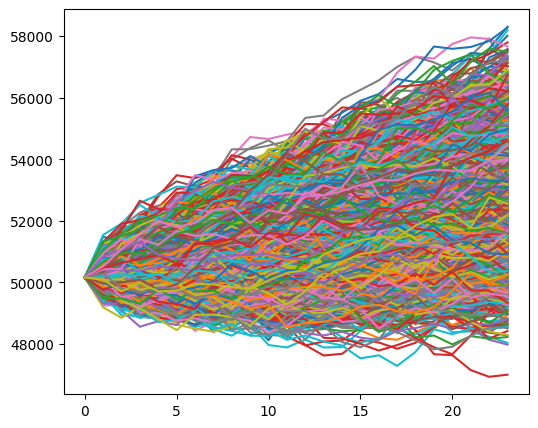

In [8]:
#[5]p営業日後までのシミュレーションをq回反復
log_returns = np.log(NKX['nikkei'] / NKX['nikkei'].shift(1)).dropna() #データフレームNKXから月次リターンを算出
mu = log_returns.mean()*12 #BSMモデルに用いる平均リターンを算出
sigma = log_returns.std() * np.sqrt(12) #BSMモデルに用いる標準偏差を算出
delta_t = 1/24 #時間の限界的経過を定義
plt.figure(figsize=(6,5))
for i in range(1,q): #p期間をq回反復シミュレーション
  for n in range(1,len(NKX_F)):
    NKX_F[n]=bsm(NKX_F[n-1],sigma,mu,delta_t,random.gauss(mu,sigma))
  plt.plot(NKX_F) #格納した試算結果を可視化
  NKX_F2[i]=NKX_F[-1]
  NKX_F3=np.delete(NKX_F2,0)

　セル[6][7]では、セル[5]の試算からもたらされる24カ月後の日経平均株価の度数分布表と、その記述統計を示しています。この結果を見ると、2027年12月30日の日経平均株価は52,858円と予測されていますが、分布が47,000円から58,000円の可能性があることを示唆しています。

[]

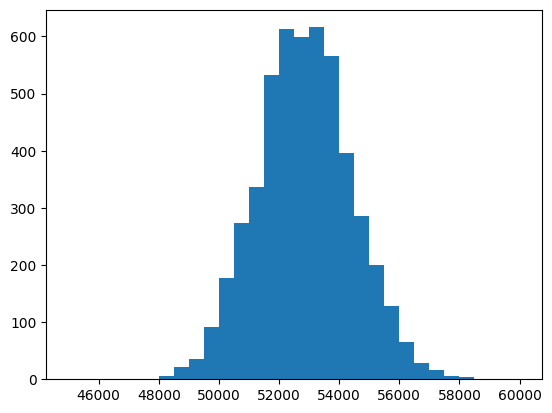

In [11]:
#[6]予測値分布の可視化
plt.hist(NKX_F3,bins=30,range=(45000,60000))
plt.plot()

In [10]:
#[7]予測値の記述統計
print('平均値 {:.3f}'.format(np.mean(NKX_F3)))
print('中央値 {:.3f}'.format(np.median(NKX_F3)))
print('標準偏差 {:.3f}'.format(np.std(NKX_F3)))
print('最大値 {:.3f}'.format(np.max(NKX_F3)))
print('最小値 {:.3f}'.format(np.min(NKX_F3)))

平均値 52858.025
中央値 52857.976
標準偏差 1570.151
最大値 58307.535
最小値 47002.914
